In [16]:
import pickle
from matplotlib import pyplot as plt
import numpy as np
import os
import json
ROOT_DIR = "/scratch/workspace/ppruthi_umass_edu-MI/task_based_cg_debugging/task_based_compositional_generalization"

In [17]:
kl_results = {}
for epsilon in [1e-10]:
    with open(f'systematic_metrics_{epsilon}.pkl', 'rb') as f:
        metrics = pickle.load(f)
    kl_results[epsilon] = metrics['step_by_step']['uniform']['abs'][2:]

In [19]:
kl_results

{1e-10: [(100,
   np.float64(5.234366385503647),
   np.float64(3.697438266795466),
   np.float64(6.771294504211828)),
  (200,
   np.float64(1.7625413987487517),
   np.float64(0.12511154204078748),
   np.float64(3.399971255456716)),
  (300,
   np.float64(1.6331712607428555),
   np.float64(0.08940688849255359),
   np.float64(3.1769356329931573)),
  (400,
   np.float64(1.473003680321862),
   np.float64(0.08301865754322929),
   np.float64(2.862988703100495)),
  (500,
   np.float64(1.2002845887429106),
   np.float64(0.09724944437856639),
   np.float64(2.3033197331072546)),
  (600,
   np.float64(2.123369158015599),
   np.float64(0.22314354054026436),
   np.float64(4.023594775490934)),
  (700,
   np.float64(0.8490900787411638),
   np.float64(0.7493791540173925),
   np.float64(0.9488010034649351))]}

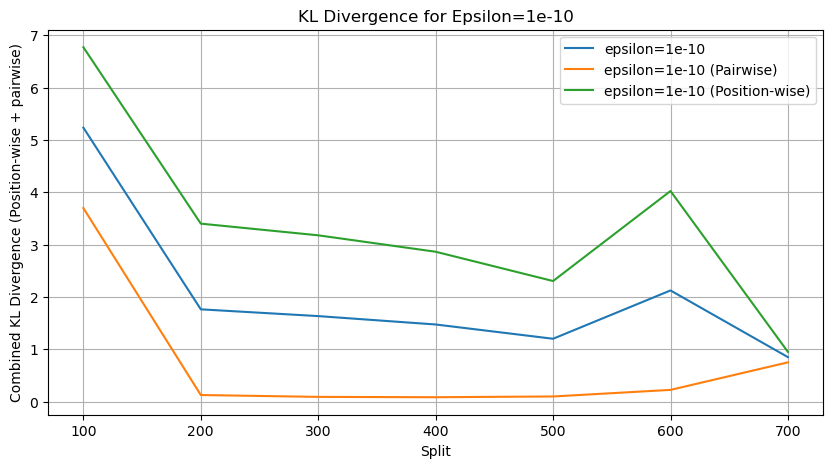

In [18]:
# plot kl_results
plt.figure(figsize=(10, 5))
for epsilon, kl in kl_results.items():
    
    # plt.figure(figsize=(10, 5))
    splits = [x[0] for x in kl]
    kl_values = [x[1] for x in kl]
    kl_position_wise = [x[2] for x in kl]
    kl_pairwise = [x[3] for x in kl]
    
    plt.plot(splits, kl_values, label=f'epsilon={epsilon}')
    plt.plot(splits, kl_position_wise, label=f'epsilon={epsilon} (Pairwise)')
    plt.plot(splits, kl_pairwise, label=f'epsilon={epsilon} (Position-wise)')
    plt.title(f'KL Divergence for Epsilon={epsilon}')
plt.legend()
plt.grid(True)
plt.xlabel('Split')
plt.ylabel('Combined KL Divergence (Position-wise + pairwise)')
plt.show()


In [10]:
splits[2:]

[100,
 200,
 300,
 400,
 500,
 600,
 700,
 1,
 10,
 100,
 200,
 300,
 400,
 500,
 600,
 700,
 1,
 10,
 100,
 200,
 300,
 400,
 500,
 600,
 700,
 1,
 10,
 100,
 200,
 300,
 400,
 500,
 600,
 700,
 1,
 10,
 100,
 200,
 300,
 400,
 500,
 600,
 700,
 1,
 10,
 100,
 200,
 300,
 400,
 500,
 600,
 700,
 1,
 10,
 100,
 200,
 300,
 400,
 500,
 600,
 700,
 1,
 10,
 100,
 200,
 300,
 400,
 500,
 600,
 700]

In [7]:
kl

[(1,
  np.float64(26.359058259199166),
  np.float64(25.687526445944258),
  np.float64(27.03059007245407)),
 (10,
  np.float64(16.870238316248418),
  np.float64(15.542377287826781),
  np.float64(18.19809934467006)),
 (100,
  np.float64(8.205443926674826),
  np.float64(5.925746424530447),
  np.float64(10.485141428819206)),
 (200,
  np.float64(2.6481510508987793),
  np.float64(0.12511154302370892),
  np.float64(5.17119055877385)),
 (300,
  np.float64(2.4555230807575303),
  np.float64(0.08940688911379953),
  np.float64(4.821639272401261)),
 (400,
  np.float64(2.192561523207362),
  np.float64(0.08301865809961337),
  np.float64(4.302104388315111)),
 (500,
  np.float64(1.7235993842407331),
  np.float64(0.09724944503485163),
  np.float64(3.3499493234466144)),
 (600,
  np.float64(3.0827796216137897),
  np.float64(0.22314355131404442),
  np.float64(5.942415691913535)),
 (700,
  np.float64(0.8490900967376698),
  np.float64(0.7493791828904697),
  np.float64(0.9488010105848699))]

In [ ]:
with open('systematic_metrics.pkl', 'rb')

# Plot from single strategy

In [13]:
K = 6
eval_path = f"{ROOT_DIR}/models/eval/diverse/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_{K}/direct"
pos = ["abs", "rel_global"]

abs_train_results_6 = []
abs_test_results_6 = []
rel_train_results_6 = []
rel_test_results_6 = []
abs_leakage_perc_list_6 = []
rel_leakage_perc_list_6 = []
strategy_prefixes = "disjoint7_6"
nine_rations = [0.0, 0.1, 0.2, 0.5, 0.6, 1.0]
seven_rations = [0.0, 0.2, 0.5, 0.6, 0.7, 1.0]
if strategy_prefixes == "disjoint7_6":
    rations = nine_rations
else:
    rations = seven_rations
for ratio in rations:

    for strategy_prefix in [strategy_prefixes]:
        for p in pos:
            perc = int(ratio * 100)
            acc_path = f"{eval_path}/train_{strategy_prefix}_{perc}/eval_{strategy_prefix}_{perc}/{p}/nh6_nl3/seed_0/accs.pkl"
            with open(acc_path, "rb") as f:
                accs = pickle.load(f)
                if p == "abs":
                    abs_train_results_6.append(accs["train_heldout"].sharp_accuracy)
                    abs_test_results_6.append(accs["test"].sharp_accuracy)
                else:
                    rel_train_results_6.append(accs["train_heldout"].sharp_accuracy)
                    rel_test_results_6.append(accs["test"].sharp_accuracy)

            leakage_perc_path = f"{ROOT_DIR}/data/equivalence_classes/{strategy_prefix.split('_')[0]}/{K}/{ratio}/number_leaked_test_tasks.json"
                
            with open(leakage_perc_path, "r") as f:
                leakage_perc = json.load(f)
                leakage_perc = leakage_perc["number_leaked_test_tasks"]
                if p == "abs":
                    abs_leakage_perc_list_6.append(leakage_perc)
                else:
                    rel_leakage_perc_list_6.append(leakage_perc)
idx = np.argsort(abs_leakage_perc_list_6)
# remove duplicates from abs_leakage_perc_list

# idx = [ idx[i] for i in [0, 2, 4, 6]]
abs_leakage_perc_list_6 = [abs_leakage_perc_list_6[i] for i in idx]
abs_train_results_6 = [abs_train_results_6[i] for i in idx]
abs_test_results_6 = [abs_test_results_6[i] for i in idx]
rel_train_results_6 = [rel_train_results_6[i] for i in idx]
rel_test_results_6 = [rel_test_results_6[i] for i in idx]
print(len(abs_leakage_perc_list_6), len(abs_test_results_6))


6 6


In [14]:
abs_leakage_perc_list = []
rel_leakage_perc_list = []
rel_plot_data = []


K = 6
eval_path = f"{ROOT_DIR}/models/eval/diverse/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_{K}/direct"

for ratio in rations:
    for strategy_prefix in [strategy_prefixes]:
        mean_accuracy_per_test_cluster = {}
        std_accuracy_per_test_cluster = {}
        for p in pos:
            perc = int(ratio * 100)
            acc_path = f"{eval_path}/train_{strategy_prefix}_{perc}/eval_{strategy_prefix}_{perc}/{p}/nh6_nl3/seed_0/accs.pkl"
            json_path = f"{ROOT_DIR}/jsons/{strategy_prefix}_{perc}_json_dict.json"
            with open(json_path, "r") as f:
                json_dict = json.load(f)
                cluster_to_function_ids = json_dict["cluster_to_function_ids"]
                cluster_to_shared_map = json_dict["cluster_to_shared_map"]
                cluster_size = json_dict["cluster_size"]
            
            leakage_perc_path = f"{ROOT_DIR}/data/equivalence_classes/{strategy_prefix.split('_')[0]}/{K}/{ratio}/number_leaked_test_tasks.json"
            
            with open(leakage_perc_path, "r") as f:
                leakage_perc = json.load(f)
                leakage_perc = leakage_perc["number_leaked_test_tasks"]
                if p == "abs":
                    abs_leakage_perc_list.append(leakage_perc)
                else:
                    rel_leakage_perc_list.append(leakage_perc)

            for cluster_id, function_ids in cluster_to_function_ids.items():
                mean_accuracy_per_test_cluster[cluster_id] = np.mean(function_ids)
                std_accuracy_per_test_cluster[cluster_id] = np.std(function_ids)
                
                # Store data for plotting only for relative global
                if p == "rel_global":
                    is_shared = cluster_to_shared_map[cluster_id]
                    size = cluster_size[cluster_id]
                    mean_acc = mean_accuracy_per_test_cluster[cluster_id]
                    std_acc = std_accuracy_per_test_cluster[cluster_id]
                    rel_plot_data.append((leakage_perc, mean_acc, std_acc, size, is_shared))



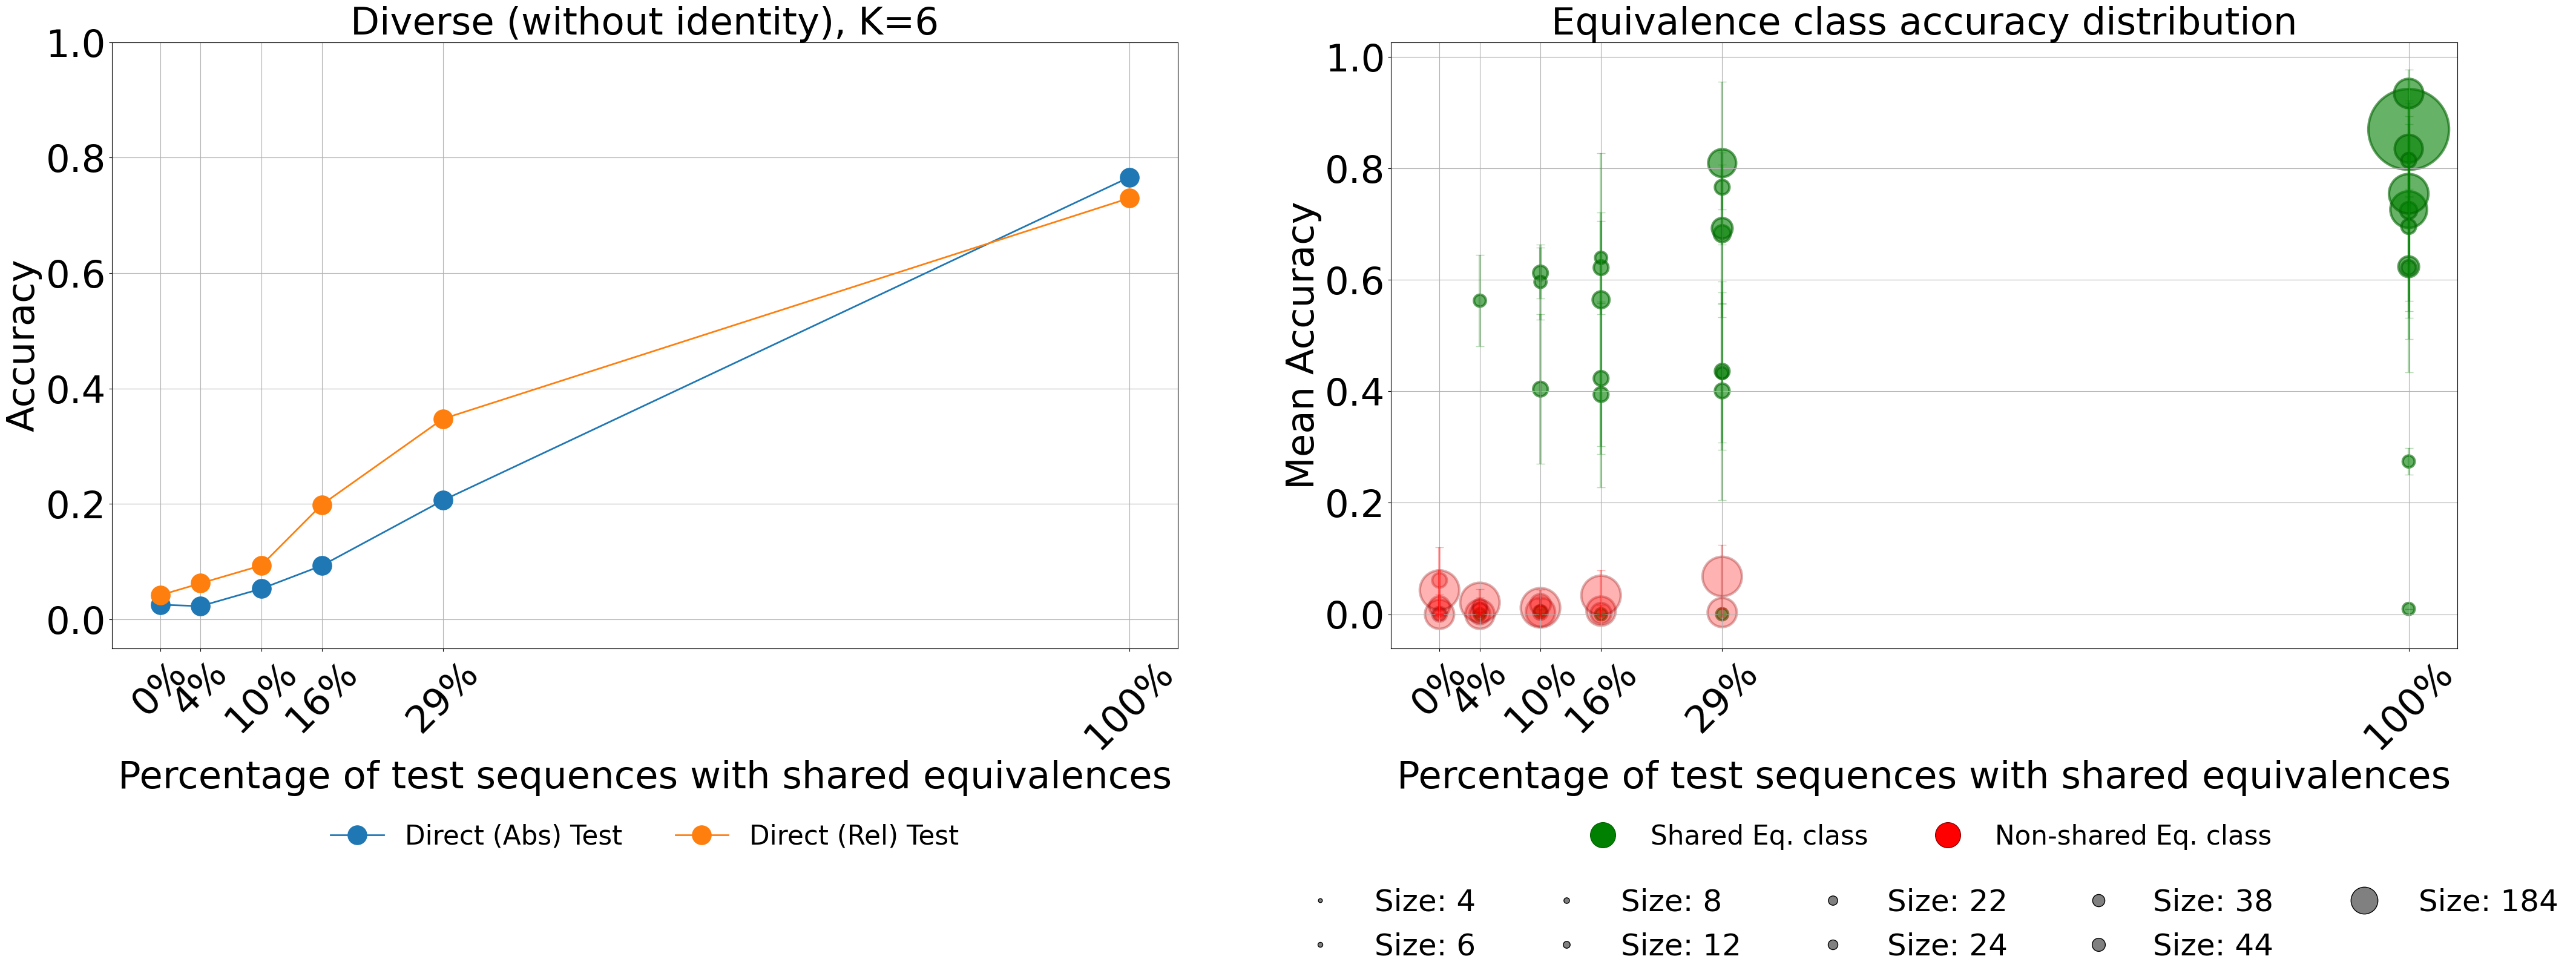

In [15]:
# plot abs_train_results and rel_train_results
from re import M
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

font_size = 45
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})

# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"

# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
        "step_by_step_direct_fixed": {"abs": "tab:purple", "rel_global": "tab:brown"},
        "direct_variable": {"abs": "tab:cyan", "rel_global": "tab:pink"},
        "step_by_step_variable": {"abs": "tab:olive", "rel_global": "tab:gray"},
        "step_by_step_direct_variable": {"abs": "tab:gray", "rel_global": "tab:olive"},
    }

fig, axs = plt.subplots(1, 2, figsize=(50, 13))

# First plot (K=6) - original line plot
x_ticks = [int(x*100) for x in abs_leakage_perc_list_6]
x_positions = [x * 100 for x in abs_leakage_perc_list_6]

# axs[0].plot(x_positions, abs_train_results_6, label="Direct (Abs) Train", linestyle="--", marker="o", markersize=font_size/2, linewidth=2)
# axs[0].plot(x_positions, rel_train_results_6, label="Direct (Rel) Train", linestyle="--", marker="o", markersize=font_size/2, linewidth=2)
axs[0].plot(x_positions, abs_test_results_6, label="Direct (Abs) Test", linestyle="-", marker="o", markersize=font_size/2, linewidth=2)
axs[0].plot(x_positions, rel_test_results_6, label="Direct (Rel) Test", linestyle="-", marker="o", markersize=font_size/2, linewidth=2)

axs[0].set_xticks(x_positions, [f"{x}%" for x in x_ticks], rotation=45)
axs[0].set_title("Diverse (without identity), K=6")
axs[0].set_xlabel("Percentage of test sequences with shared equivalences")
axs[0].set_ylabel("Accuracy")
axs[0].grid(True)
# set y-lim
axs[0].set_ylim(-0.05, 1.0)
# Add legend for left plot below it
axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=font_size*0.7, frameon=False)

# Second plot (K=4) - cluster visualization with error bars
# Separate shared and non-shared clusters
shared_data = [(lp, ma, sa, sz) for lp, ma, sa, sz, is_s in rel_plot_data if is_s]
non_shared_data = [(lp, ma, sa, sz) for lp, ma, sa, sz, is_s in rel_plot_data if not is_s]

# Get all cluster sizes for proportional sizing
all_sizes = [sz for _, _, _, sz, _ in rel_plot_data]
unique_sizes = sorted(set(all_sizes))

# Scale factor for marker sizes (adjust as needed for visibility)
size_scale_factor = 50

# Plot shared clusters (GREEN)
if shared_data:
    leakage_percs, mean_accs, std_accs, sizes = zip(*shared_data)
    # Size proportional to cluster size
    marker_sizes = [s * size_scale_factor for s in sizes]
    # Convert to percentage
    leakage_percs_pct = [lp * 100 for lp in leakage_percs]
    axs[1].errorbar(leakage_percs_pct, mean_accs, yerr=std_accs, fmt='none', 
                ecolor='green', alpha=0.3, capsize=5, linewidth=3)
    axs[1].scatter(leakage_percs_pct, mean_accs, s=marker_sizes, c='green', 
               alpha=0.6, edgecolors='darkgreen', linewidth=3)

# Plot non-shared clusters (RED)
if non_shared_data:
    leakage_percs, mean_accs, std_accs, sizes = zip(*non_shared_data)
    # Size proportional to cluster size
    marker_sizes = [s * size_scale_factor for s in sizes]
    # Convert to percentage
    leakage_percs_pct = [lp * 100 for lp in leakage_percs]
    axs[1].errorbar(leakage_percs_pct, mean_accs, yerr=std_accs, fmt='none', 
                ecolor='red', alpha=0.3, capsize=5, linewidth=3)
    axs[1].scatter(leakage_percs_pct, mean_accs, s=marker_sizes, c='red', 
               alpha=0.3, edgecolors='darkred', linewidth=3)

# Get all unique leakage percentages and set them as x-ticks
unique_leakage_percs = sorted(set([lp for lp, _, _, _, _ in rel_plot_data]))
unique_leakage_percs_pct = [lp * 100 for lp in unique_leakage_percs]
axs[1].set_xticks(unique_leakage_percs_pct)
axs[1].set_xticklabels([f'{int(lp)}%' for lp in unique_leakage_percs_pct], rotation=45)

axs[1].set_title("Equivalence class accuracy distribution")
axs[1].set_xlabel("Percentage of test sequences with shared equivalences")
axs[1].set_ylabel("Mean Accuracy")
axs[1].grid(True)

# Create custom legend elements with constant size for shared/non-shared
color_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Shared Eq. class',
           markerfacecolor='green', markeredgecolor='darkgreen', 
           markersize=30, linewidth=2),
           
    Line2D([0], [0], marker='o', color='w', label='Non-shared Eq. class',
           markerfacecolor='red', markeredgecolor='darkred', 
           markersize=30, linewidth=2)
]

# Add color legend with constant size markers
color_legend = axs[1].legend(handles=color_legend_elements, loc='upper center', 
                             bbox_to_anchor=(0.5, -0.25), ncol=2, 
                             fontsize=font_size*0.7, frameon=False)

# Create size legend showing cluster sizes proportionally
size_legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Size: {size}',
                              markerfacecolor='gray', markeredgecolor='black', 
                              markersize=np.sqrt(size * size_scale_factor) / 3, linewidth=2) 
                       for size in unique_sizes]

# Add size legend below the color legend for right plot
axs[1].add_artist(color_legend)
axs[1].legend(handles=size_legend_elements, loc='upper center', 
              bbox_to_anchor=(0.5, -0.35), ncol=5,
              fontsize=font_size*0.8, frameon=False)

# save as PDF
plt.savefig("rebuttal_plots/leakage_experiment_diverse_k6_equivalence_class_disjoint7.pdf", bbox_inches="tight")
plt.savefig("rebuttal_plots/leakage_experiment_diverse_k6_equivalence_class_disjoint7.png", bbox_inches="tight")

In [16]:
non_shared_data

[(0.0, np.float64(0.0), np.float64(0.0), 24),
 (0.0, np.float64(0.01362179487179487), np.float64(0.022017037923131547), 12),
 (0.0, np.float64(0.0608974358974359), np.float64(0.05944627240702374), 6),
 (0.0, np.float64(0.04326923076923077), np.float64(0.036700276582571204), 44),
 (0.0, np.float64(0.0), np.float64(0.0), 4),
 (0.0, np.float64(0.0), np.float64(0.0), 6),
 (0.041666666666666664, np.float64(0.0), np.float64(0.0), 24),
 (0.041666666666666664,
  np.float64(0.0008012820512820514),
  np.float64(0.002657551915348878),
  12),
 (0.041666666666666664,
  np.float64(0.014423076923076922),
  np.float64(0.015454568527232301),
  6),
 (0.041666666666666664,
  np.float64(0.02119755244755245),
  np.float64(0.024219557833231473),
  44),
 (0.041666666666666664,
  np.float64(0.008012820512820514),
  np.float64(0.01406244292851302),
  6),
 (0.10416666666666667,
  np.float64(0.004006410256410257),
  np.float64(0.01035484614048084),
  24),
 (0.10416666666666667,
  np.float64(0.01762820512820513),

In [ ]:
mean

# Plot from multiple strategies

7 7
[0.0, 0.7964601769911505, 0.8938053097345132, 0.9469026548672567, 0.9734513274336283, 0.9867256637168141, 1.0]
[0.9287011027336121, 0.9204316139221191, 0.9067164063453674, 0.9110528230667114, 0.9144816398620605, 0.9130697846412659, 0.9112545251846313]


Text(0, 0.5, 'Accuracy')

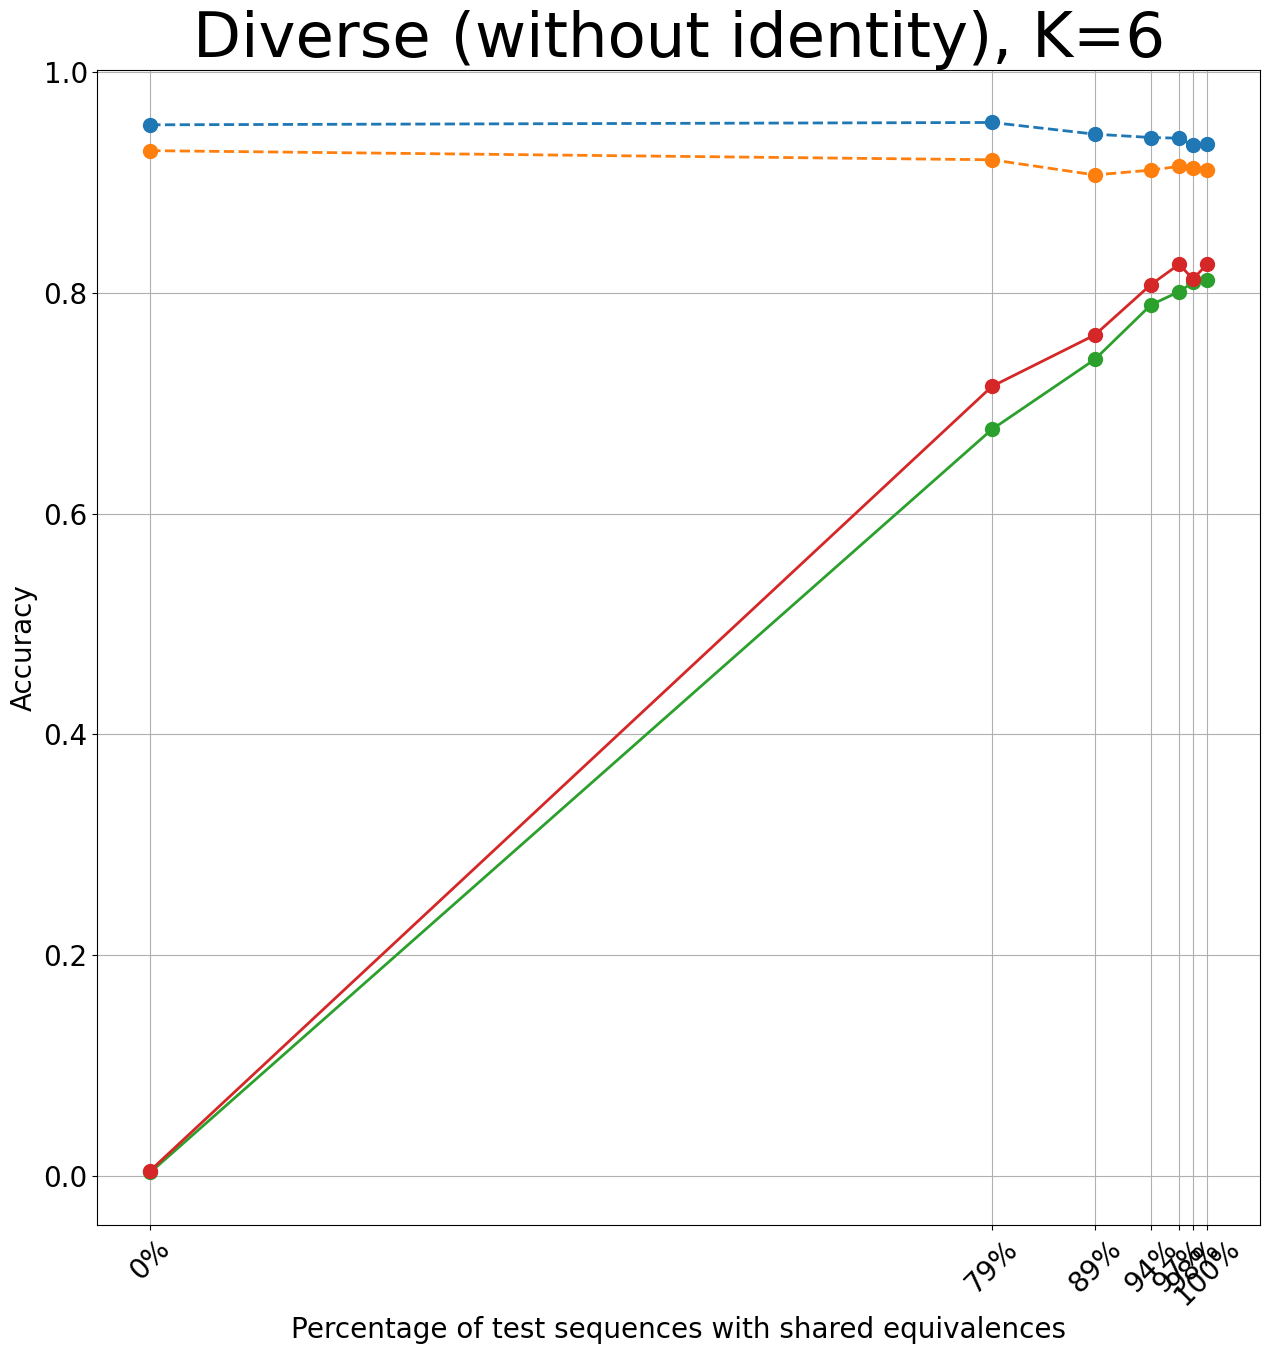

In [51]:
pos = ["abs", "rel_global"]

abs_train_results_6 = []
abs_test_results_6 = []
rel_train_results_6 = []
rel_test_results_6 = []
abs_leakage_perc_list = []
rel_leakage_perc_list = []
six_rations = [0.0, 0.1, 0.2, 0.5, 0.6, 0.7, 1.0]
four_rations = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
K = 6
eval_path = f"{ROOT_DIR}/models/eval/diverse/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_{K}/direct"
for ratio in six_rations:
    for strategy_prefix in [f"disjoint5_{K}"]:
        for p in pos:
            perc = int(ratio * 100)
            acc_path = f"{eval_path}/train_{strategy_prefix}_{perc}/eval_{strategy_prefix}_{perc}/{p}/nh6_nl3/seed_0/accs.pkl"
            # if not os.path.exists(acc_path):
            #     continue
            with open(acc_path, "rb") as f:
                accs = pickle.load(f)
                if p == "abs":
                    abs_train_results_6.append(accs["train_heldout"].sharp_accuracy)
                    abs_test_results_6.append(accs["test"].sharp_accuracy)
                else:
                    rel_train_results_6.append(accs["train_heldout"].sharp_accuracy)
                    rel_test_results_6.append(accs["test"].sharp_accuracy)
            
            leakage_perc_path = f"{ROOT_DIR}/data/equivalence_classes/{strategy_prefix.split('_')[0]}/{K}/{ratio}/number_leaked_test_tasks.json"
            
            with open(leakage_perc_path, "r") as f:
                leakage_perc = json.load(f)
                leakage_perc = leakage_perc["number_leaked_test_tasks"]
                if p == "abs":
                    abs_leakage_perc_list.append(leakage_perc)
                else:
                    rel_leakage_perc_list.append(leakage_perc)

print(len(abs_leakage_perc_list), len(abs_test_results_6))

idx = np.argsort(abs_leakage_perc_list)
print(abs_leakage_perc_list)
print(rel_train_results_6)
# remove duplicates from abs_leakage_perc_list

# idx = [ idx[i] for i in [0, 2, 4, 6]]
abs_leakage_perc_list = [abs_leakage_perc_list[i] for i in idx]
abs_train_results_6 = [abs_train_results_6[i] for i in idx]
abs_test_results_6 = [abs_test_results_6[i] for i in idx]
rel_train_results_6 = [rel_train_results_6[i] for i in idx]
rel_test_results_6 = [rel_test_results_6[i] for i in idx]



font_size = 20
idx = np.argsort(abs_leakage_perc_list)
# remove duplicates from abs_leakage_perc_list

# idx = [ idx[i] for i in [0, 2, 4, 6]]
plt.figure(figsize=(15, 15))
abs_leakage_perc_list = [abs_leakage_perc_list[i] for i in idx]
abs_train_results = [abs_train_results_6[i] for i in idx]
abs_test_results = [abs_test_results_6[i] for i in idx]
rel_train_results = [rel_train_results_6[i] for i in idx]
rel_test_results = [rel_test_results_6[i] for i in idx]

# Use actual leakage percentage values for x-axis positions
x_positions = [x * 100 for x in abs_leakage_perc_list]

plt.plot(x_positions, abs_train_results, label="Direct (Abs) Train", linestyle="--", marker="o", markersize=font_size/2, linewidth=2)
plt.plot(x_positions, rel_train_results, label="Direct (Rel) Train", linestyle="--", marker="o", markersize=font_size/2, linewidth=2)
plt.plot(x_positions, abs_test_results, label="Direct (Abs) Test", linestyle="-", marker="o", markersize=font_size/2, linewidth=2)
plt.plot(x_positions, rel_test_results, label="Direct (Rel) Test", linestyle="-", marker="o", markersize=font_size/2, linewidth=2)
x_ticks = [ int(x*100) for x in abs_leakage_perc_list]
# 
# xlabels has % of tasks with shared equivalences
plt.xticks(x_positions, [f"{x}%" for x in x_ticks], rotation=45, fontsize=font_size)
# set fontsize of yticks to font_size, just size 10
plt.tick_params(axis='y', labelsize=font_size)
# grid lines
plt.grid(True)
plt.title("Diverse (without identity), K=6")
plt.xlabel("Percentage of test sequences with shared equivalences", fontsize=font_size)
plt.ylabel("Accuracy", fontsize=font_size)






In [ ]:
# Plot accuracy distribution plot


# Selected_splits
K= 6: "disjoint9_6"


K = 4: ?


# Plot accuracy distribution


In [53]:
pos = ["abs", "rel_global"]

abs_train_results_6 = []
abs_test_results_6 = []
rel_train_results_6 = []
rel_test_results_6 = []
abs_leakage_perc_list = []
rel_leakage_perc_list = []

six_rations = [0.0, 0.1, 0.2, 0.5, 0.6, 0.7, 1.0]
four_rations = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
K = 6
eval_path = f"{ROOT_DIR}/models/eval/diverse/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_{K}/direct"
for ratio in six_rations:
    for strategy_prefix in [f"disjoint7_{K}"]:
        mean_accuracy_per_test_cluster = {}
        std_accuracy_per_test_cluster = {}
        for p in pos:
            perc = int(ratio * 100)
            acc_path = f"{eval_path}/train_{strategy_prefix}_{perc}/eval_{strategy_prefix}_{perc}/{p}/nh6_nl3/seed_0/accs.pkl"
            json_path = f"{ROOT_DIR}/{strategy_prefix}_{perc}_json_dict.json"
            with open(json_path, "r") as f:
                json_dict = json.load(f)
                cluster_to_function_ids = json_dict["cluster_to_function_ids"]
                cluster_to_shared_map = json_dict["cluster_to_shared_map"]
                cluster_size = json_dict["cluster_size"]
            
            leakage_perc_path = f"{ROOT_DIR}/data/equivalence_classes/{strategy_prefix.split('_')[0]}/{K}/{ratio}/number_leaked_test_tasks.json"
            
            with open(leakage_perc_path, "r") as f:
                leakage_perc = json.load(f)
                leakage_perc = leakage_perc["number_leaked_test_tasks"]
                if p == "abs":
                    abs_leakage_perc_list.append(leakage_perc)
                else:
                    rel_leakage_perc_list.append(leakage_perc)

            for cluster_id, function_ids in cluster_to_function_ids.items():
                mean_accuracy_per_test_cluster[cluster_id] = np.mean(function_ids)
                std_accuracy_per_test_cluster[cluster_id] = np.std(function_ids)
                

1 24 False 0.0 0.0
3 12 False 0.01362179487179487 0.022017037923131547
6 6 False 0.0608974358974359 0.05944627240702374
8 44 False 0.04326923076923077 0.036700276582571204
9 4 False 0.0 0.0
11 6 False 0.0 0.0
1 24 False 0.0 0.0
3 12 False 0.01362179487179487 0.022017037923131547
6 6 False 0.0608974358974359 0.05944627240702374
8 44 False 0.04326923076923077 0.036700276582571204
9 4 False 0.0 0.0
11 6 False 0.0 0.0
1 24 False 0.0 0.0
3 12 False 0.0008012820512820514 0.002657551915348878
6 6 False 0.014423076923076922 0.015454568527232301
8 44 False 0.02119755244755245 0.024219557833231473
9 4 True 0.0 0.0
11 6 False 0.008012820512820514 0.01406244292851302
13 4 True 0.5625 0.08173076923076925
1 24 False 0.0 0.0
3 12 False 0.0008012820512820514 0.002657551915348878
6 6 False 0.014423076923076922 0.015454568527232301
8 44 False 0.02119755244755245 0.024219557833231473
9 4 True 0.0 0.0
11 6 False 0.008012820512820514 0.01406244292851302
13 4 True 0.5625 0.08173076923076925
1 24 False 0.004

ValueError: x and y must have same first dimension, but have shapes (6,) and (0,)

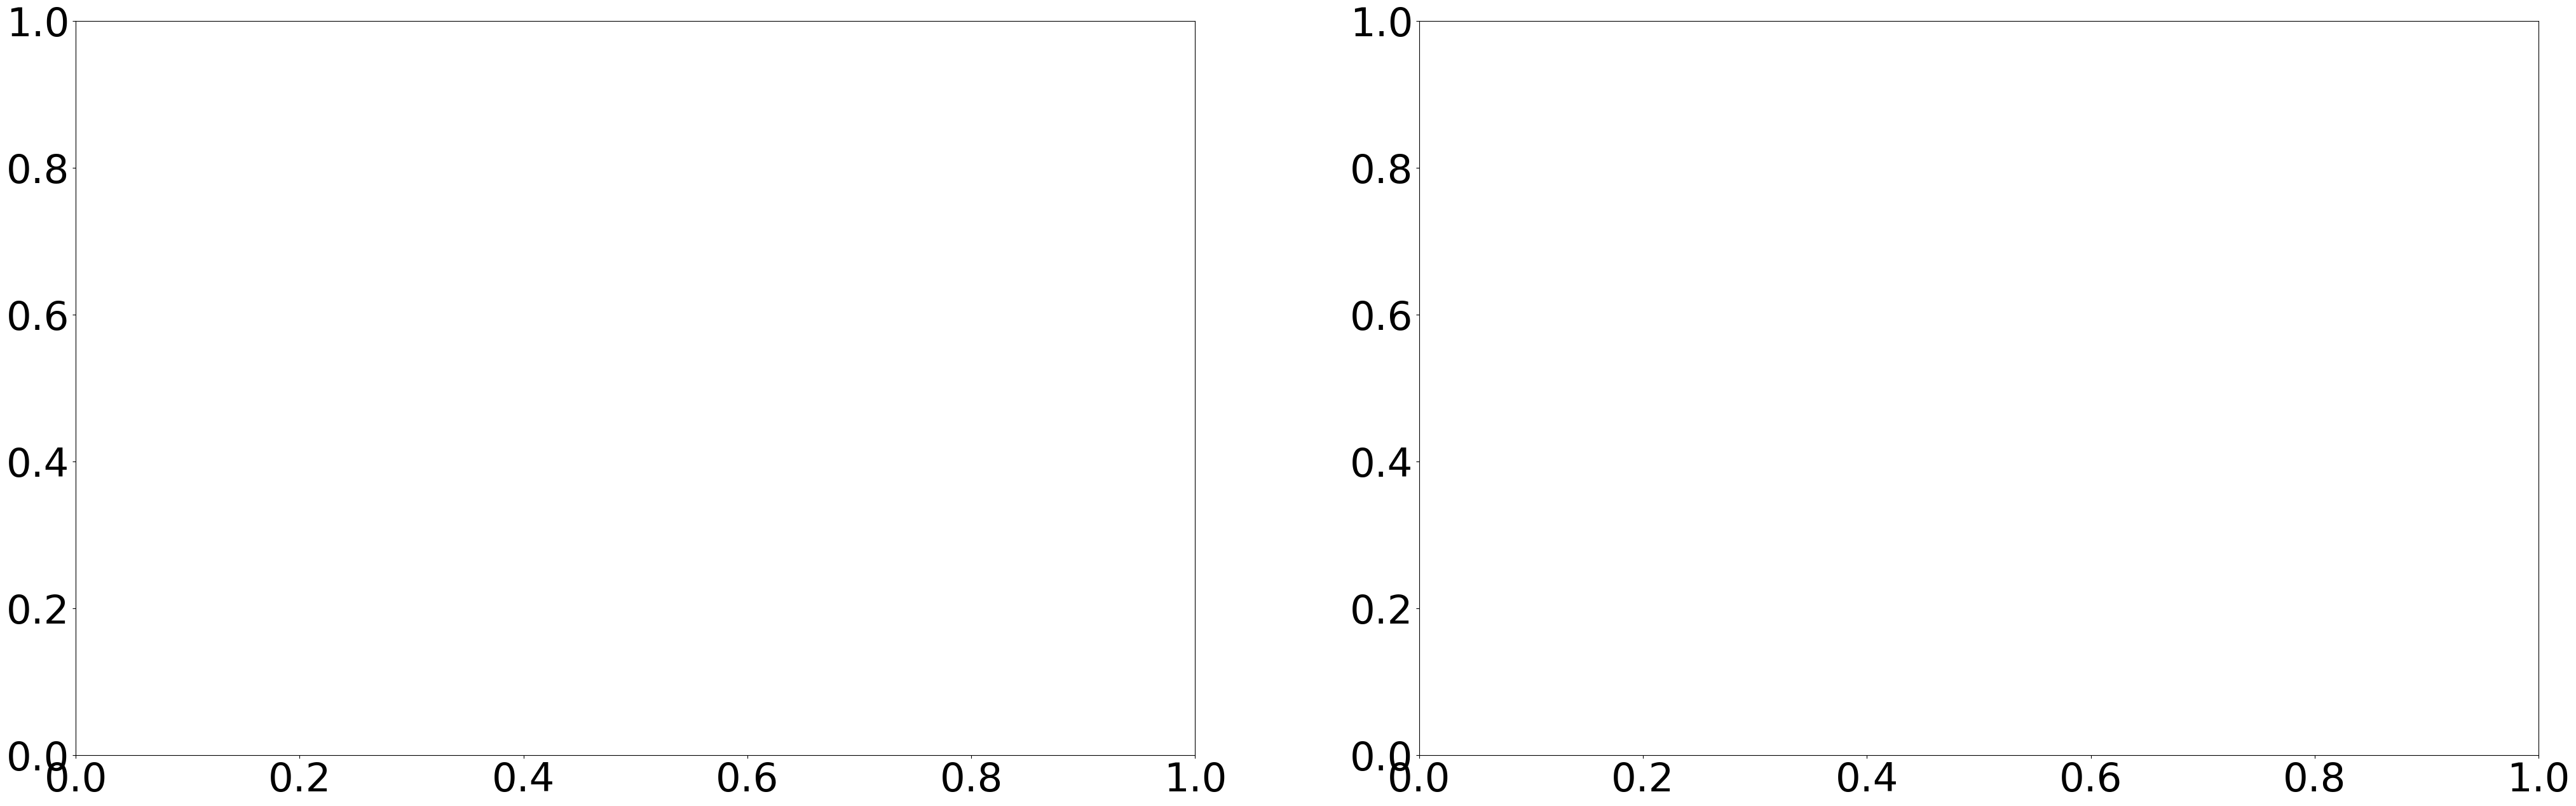

In [ ]:
# plot abs_train_results and rel_train_results
from re import M
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

font_size = 45
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})

# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"

# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
        "step_by_step_direct_fixed": {"abs": "tab:purple", "rel_global": "tab:brown"},
        "direct_variable": {"abs": "tab:cyan", "rel_global": "tab:pink"},
        "step_by_step_variable": {"abs": "tab:olive", "rel_global": "tab:gray"},
        "step_by_step_direct_variable": {"abs": "tab:gray", "rel_global": "tab:olive"},
    }

fig, axs = plt.subplots(1, 2, figsize=(50, 15))

# First plot (K=6) - original line plot
x_ticks = [int(x*100) for x in abs_leakage_perc_list_6]
x_positions = [x * 100 for x in abs_leakage_perc_list_6]

axs[0].plot(x_positions, abs_train_results_6, label="Direct (Abs) Train", linestyle="--", marker="o", markersize=font_size/2, linewidth=2)
axs[0].plot(x_positions, rel_train_results_6, label="Direct (Rel) Train", linestyle="--", marker="o", markersize=font_size/2, linewidth=2)
axs[0].plot(x_positions, abs_test_results_6, label="Direct (Abs) Test", linestyle="-", marker="o", markersize=font_size/2, linewidth=2)
axs[0].plot(x_positions, rel_test_results_6, label="Direct (Rel) Test", linestyle="-", marker="o", markersize=font_size/2, linewidth=2)

axs[0].set_xticks(x_positions, [f"{x}%" for x in x_ticks], rotation=45)
axs[0].set_title("Diverse (without identity), K=6")
axs[0].set_xlabel("Percentage of test sequences with shared equivalences")
axs[0].set_ylabel("Accuracy")
axs[0].grid(True)

# Add legend for left plot below it
axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=font_size*0.7, frameon=False)

# Second plot (K=4) - cluster visualization with error bars
# Separate shared and non-shared clusters
shared_data = [(lp, ma, sa, sz) for lp, ma, sa, sz, is_s in rel_plot_data if is_s]
non_shared_data = [(lp, ma, sa, sz) for lp, ma, sa, sz, is_s in rel_plot_data if not is_s]

# Get all cluster sizes for proportional sizing
all_sizes = [sz for _, _, _, sz, _ in rel_plot_data]
unique_sizes = sorted(set(all_sizes))

# Scale factor for marker sizes (adjust as needed for visibility)
size_scale_factor = 50

# Plot shared clusters (GREEN)
if shared_data:
    leakage_percs, mean_accs, std_accs, sizes = zip(*shared_data)
    # Size proportional to cluster size
    marker_sizes = [s * size_scale_factor for s in sizes]
    # Convert to percentage
    leakage_percs_pct = [lp * 100 for lp in leakage_percs]
    axs[1].errorbar(leakage_percs_pct, mean_accs, yerr=std_accs, fmt='none', 
                ecolor='green', alpha=0.3, capsize=5, linewidth=3)
    axs[1].scatter(leakage_percs_pct, mean_accs, s=marker_sizes, c='green', 
               alpha=0.6, label='Shared', edgecolors='darkgreen', linewidth=3)

# Plot non-shared clusters (RED)
if non_shared_data:
    leakage_percs, mean_accs, std_accs, sizes = zip(*non_shared_data)
    # Size proportional to cluster size
    marker_sizes = [s * size_scale_factor for s in sizes]
    # Convert to percentage
    leakage_percs_pct = [lp * 100 for lp in leakage_percs]
    axs[1].errorbar(leakage_percs_pct, mean_accs, yerr=std_accs, fmt='none', 
                ecolor='red', alpha=0.3, capsize=5, linewidth=3)
    axs[1].scatter(leakage_percs_pct, mean_accs, s=marker_sizes, c='red', 
               alpha=0.6, label='Non-shared', edgecolors='orange', linewidth=3)

# Get all unique leakage percentages and set them as x-ticks
unique_leakage_percs = sorted(set([lp for lp, _, _, _, _ in rel_plot_data]))
unique_leakage_percs_pct = [lp * 100 for lp in unique_leakage_percs]
axs[1].set_xticks(unique_leakage_percs_pct)
axs[1].set_xticklabels([f'{int(lp)}%' for lp in unique_leakage_percs_pct], rotation=45)

axs[1].set_title("Test equivalence class accuracy distribution")
axs[1].set_xlabel("Percentage of test sequences with shared equivalences")
axs[1].set_ylabel("Mean Accuracy")
axs[1].grid(True, alpha=0.3)

# Add color legend for right plot
axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=font_size*0.7, frameon=False)

# Create size legend showing cluster sizes proportionally
size_legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Size: {size}',
                              markerfacecolor='gray', markeredgecolor='black', 
                              markersize=np.sqrt(size * size_scale_factor) / 3, linewidth=2) 
                       for size in unique_sizes]

# Add size legend below the color legend for right plot
size_legend = axs[1].legend(handles=size_legend_elements, loc='upper center', 
                            bbox_to_anchor=(0.5, -0.35), ncol=4,
                            fontsize=font_size*0.6, frameon=False, title="Cluster Sizes")

# Add the color legend back (since legend() replaces the previous one)
axs[1].add_artist(axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), 
                                 ncol=2, fontsize=font_size*0.7, frameon=False))

# save as PDF
plt.savefig("rebuttal_plots/leakage_experiment_diverse_k6_cluster.pdf", bbox_inches="tight")
plt.savefig("rebuttal_plots/leakage_experiment_diverse_k6_cluster.png", bbox_inches="tight")

In [2]:
# SBS Analysis
import pickle
acc_path = "/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/models/eval/diverse/nalph_26_seqlen_6_fnlen_6_taskmaxlen_6/step_by_step/fixed/model_permutation_6_50/eval_permutation_6_50/abs/nh6_nl3/seed_0/accs.pkl"
with open(acc_path, "rb") as f:
    accs = pickle.load(f)
accs = accs[0]
ck, metrics = accs
metrics.keys()

train_metrics = metrics["train_heldout"]
test_metrics = metrics["test"]
# plot abs_train_results and rel_train_results
test_metrics.keys()



dict_keys(['total', 'combination', 'module_wise', 'step_by_step', 'direct', 'total_unique_combination_ids', 'print_error_indices'])

In [ ]:
test_metrics["step_by_step"]["cumulative"]

KeyError: 'cumulative'